# **Analyis of Reports in the City of Zurich**

The primary objective of this analysis is to examine the Züri wie neu dataset in order to identify spatial and temporal patterns. To achieve this, various visualization techniques will be applied. In addition, a secondary dataset containing waste container locations will be integrated to investigate whether their spatial distribution has an influence on the frequency of waste-related (“Abfall/Sammelstelle”) reports across different districts.

The Züri wie neu dataset contains citizen-reported issues regarding damage and defects in public infrastructure within the City of Zurich. It includes reports of various types of urban maintenance problems, such as potholes in road surfaces, graffiti on public buildings, or vandalized park benches.

In [39]:
import geopandas as gpd
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from esda.moran import Moran
from libpysal.weights import Queen

# 1. Load the Data 

Before conducting the analysis, the report data is spatially joined with Zurich's district polygons. This allows each report to be assigned to a specific neighbourhood. Report counts are then standardised by district area (km²) to ensure comparability between districts of different sizes.

In [29]:
# Load preprocessed data
reports_gdf = gpd.read_file("../data/processed/reports_gdf.gpkg")
quartiere_gdf = gpd.read_file("../data/processed/quartiere.gpkg")
lakes_gdf = gpd.read_file("../data/processed/zurichsee.gpkg")

# Spatial Join: assign each report to a district
reports_gdf = reports_gdf

reports_quartiere_gdf = gpd.sjoin(reports_gdf, quartiere_gdf, how="inner", predicate="within")

# Aggregate number of reports per district
report_counts = reports_quartiere_gdf.groupby("name").size().reset_index(name="count")

# Merge aggregated counts back to district geometries
quartiere_counts_gdf = quartiere_gdf.merge(report_counts, on="name", how="left")

# Handle missing values and compute report denisty per km2
quartiere_counts_gdf["count"] = quartiere_counts_gdf["count"].fillna(0)
quartiere_counts_gdf["density"] = quartiere_counts_gdf["count"] / quartiere_counts_gdf["area_km2"]

# 2. Exploratory Spatial Analysis 
This section explores the spatial distribution of reported incidents across the city of Zurich. The goal is to identify initial spatial patterns, clustering effects, and potential hotspots. To achieve this, three visualization approaches are used: a point distribution map, a choropleth map aggregated by district, and a kernel density estimation (KDE) surface. Together, these methods provide both detailed and smoothed perspectives on the spatial structure of the data.

## 2.1 Point Distribution

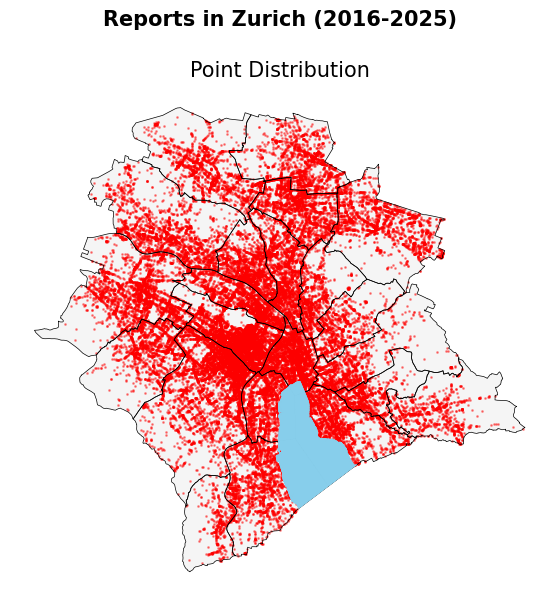

In [30]:
fig, ax = plt.subplots(1, 1, figsize=(7, 6))
fig.suptitle("Reports in Zurich (2016-2025)", fontsize=15, x=0.5, y=1.001, fontweight="bold")

quartiere_gdf.plot(ax=ax, color="whitesmoke", linewidth=0.5, zorder=1)
reports_gdf.plot(ax=ax, color="red", markersize=1, alpha=0.4, zorder=2)
lakes_gdf.plot(ax=ax, color="skyblue", zorder=4)
quartiere_gdf.boundary.plot(ax=ax, color="black", linewidth=0.5, zorder=3)

ax.axis("off")
ax.set_title("Point Distribution", fontsize=15)

plt.tight_layout()
plt.savefig("../outputs/point_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

The point distribution map shows the raw locations of all reported incidents across the city. Without any aggregation, individual events are visible in their exact spatial context. A clear concentration of reports can already be observed in the central parts of Zurich, while peripheral areas appear significantly less dense.

## 2.2 Choropleth (by district density)

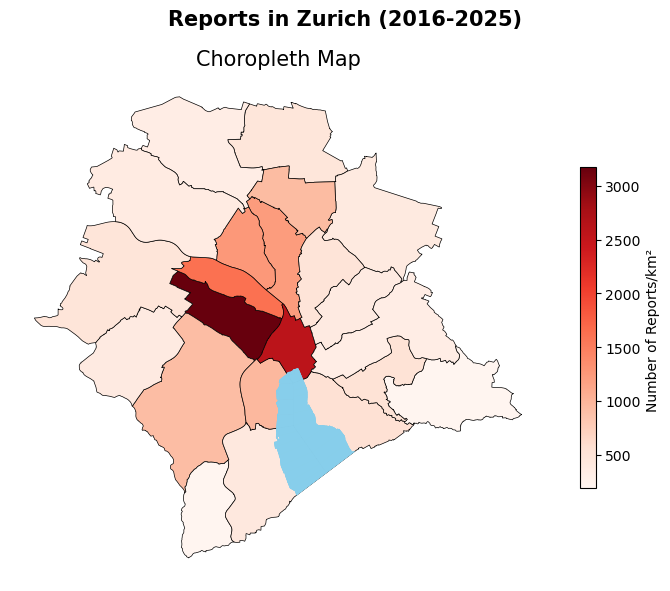

In [31]:
# 2. Choropleth Map
fig, ax = plt.subplots(1, 1, figsize=(7, 6))
fig.suptitle("Reports in Zurich (2016-2025)", fontsize=15, x=0.5, y=1.001, fontweight="bold")

lakes_gdf.plot(ax=ax, color="skyblue", zorder=2)

quartiere_counts_gdf.plot(
    column="density",
    cmap="Reds",
    legend=True,
    legend_kwds={"label": "Number of Reports/km² ", "orientation": "vertical", "shrink": 0.6},
    edgecolor="black",
    linewidth=0.5,
    ax=ax,
    zorder=1)

ax.set_title("Choropleth Map", fontsize=15)
ax.axis("off")

plt.tight_layout()
plt.savefig("../outputs/choropleth_map.png", dpi=300, bbox_inches="tight")
plt.show()

The choropleth map aggregates the number of reports at the district level and normalizes them by area (km²). This adjustment allows for meaningful comparison between districts of different sizes. The resulting pattern highlights strong spatial inequalities, with central districts (mostly Aussershil and Altstadt) showing substantially higher report densities than outer residential areas. This suggests that urban core areas experience a higher concentration of reported issues, likely due to more intensive public space usage.

## 2.3 Kernel Density Estimate (KDE) Heatmap
The KDE heatmap provides a smoothed representation of reporting intensity across space. Instead of showing discrete points, it estimates continuous density surfaces, making clusters and hotspots more visually apparent. While this approach is useful for identifying general spatial trends, it introduces smoothing effects that may obscure fine-scale variation. Therefore, the results should be interpreted as indicative patterns rather than precise measurements.

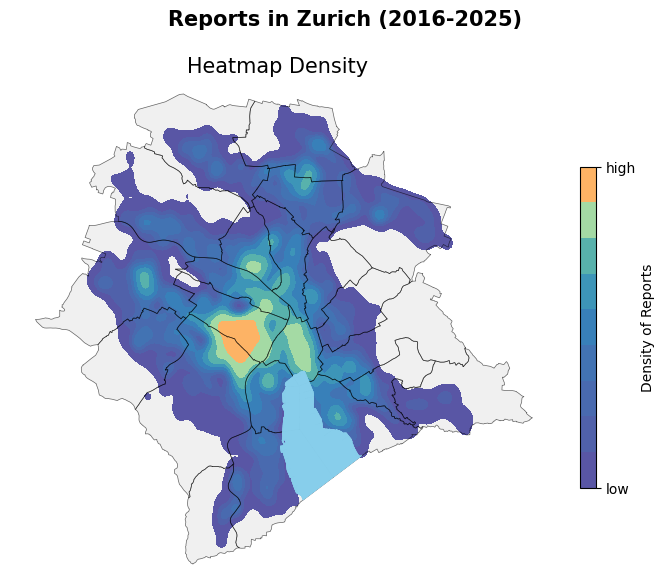

In [32]:
# 3. Heatmap (Kernel Density Estimate)
fig, ax = plt.subplots(1, 1, figsize=(7, 6))
fig.suptitle("Reports in Zurich (2016-2025)", fontsize=15, x=0.5, y=1.001, fontweight="bold")

quartiere_gdf.plot(ax=ax, color="#f0f0f0", edgecolor="none")

sns.kdeplot(
    x=reports_gdf.e,
    y=reports_gdf.n,
    ax=ax,
    cmap="Spectral_r",
    fill=True,
    thresh=0.05,
    cbar=True,
    cbar_kws={"label": "Density of Reports", "orientation": "vertical", "shrink": 0.6},
    bw_adjust=0.5
)

cbar = ax.collections[-1].colorbar
vmin, vmax = cbar.ax.get_ylim()
cbar.set_ticks([vmin, vmax])
cbar.set_ticklabels(["low", "high"])

lakes_gdf.plot(ax=ax, color="skyblue", zorder=2)
quartiere_gdf.boundary.plot(ax=ax, color="black", linewidth=0.5, alpha=0.6, zorder=1)

ax.axis("off")
ax.set_title("Heatmap Density", fontsize=15)

plt.tight_layout()
plt.savefig("../outputs/heatmap_density.png", dpi=300, bbox_inches="tight")
plt.show()

The KDE heatmap provides a smoothed representation of reporting intensity across space. Instead of showing discrete points, it estimates continuous density surfaces, making clusters and hotspots more visually apparent. While this approach is useful for identifying general spatial trends, it introduces smoothing effects that may obscure fine-scale variation. Therefore, the results should be interpreted as indicative patterns rather than precise measurements.

## 2.4 Histogram of Number of Reports per District

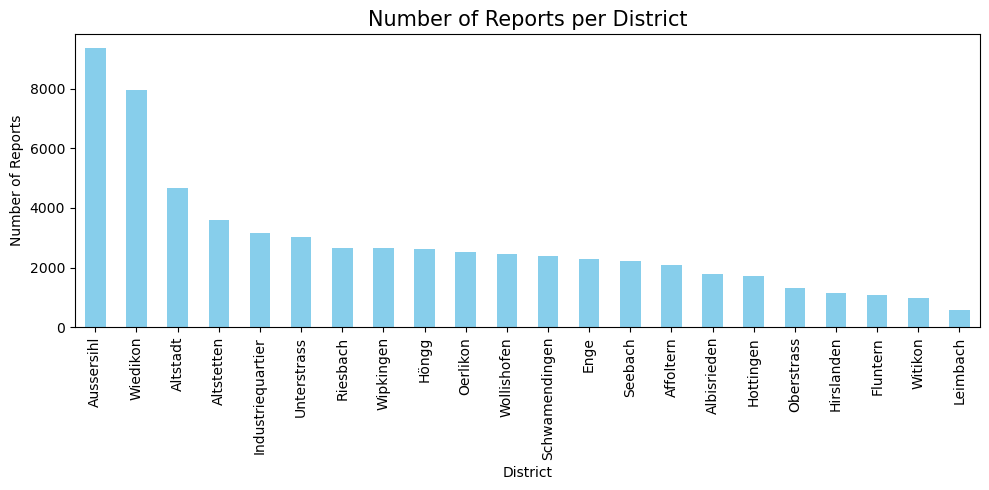

In [33]:
# Historam of number of reports per district
fig, ax = plt.subplots(figsize=(10,5))

reports_quartiere_gdf["name"].value_counts().plot(kind="bar", ax=ax, color="skyblue")

ax.set_title("Number of Reports per District", fontsize=15)
ax.set_ylabel("Number of Reports")
ax.set_xlabel("District")

plt.tight_layout()
plt.savefig("../outputs/reports_per_district.png", dpi=300, bbox_inches="tight")
plt.show()

The histogram shows a strongly uneven distribution of reported incidents across Zurich’s districts. A small number of districts clearly stand out as outliers, with Aussersihl showing the highest number of reports, followed by Wiedikon and, to a lesser extent, the Altatadt. These districts have significantly higher values compared to the rest of the city.

In contrast, most other districts are relatively close to each other in terms of total report counts, forming a fairly compact middle range without strong variation. At the lower end of the distribution, Leimbach records the lowest number of reports.

Overall, the pattern suggests that reporting activity is highly concentrated in a few central or densely used districts, while the majority of districts experience comparatively similar and lower levels of reported incidents.

## 2.5 Spatial Autocorrelation (Global Moran's I)
Spatial autocorrelation measures whether similar values tend to occur close to each other in geographic space or whether they are randomly distributed. In this analysis, Global Moran’s I is used to test whether the density of reports across Zurich’s districts shows a statistically structured spatial pattern. The statistic compares the value of each district with the values of its neighboring districts based on a spatial weights matrix. A positive value indicates clustering of similar values, while a value close to zero suggests randomness.

Queen contiguity is a method for defining spatial neighbors in geographic data. Two areas are considered neighbors if they share either a common boundary or a single corner point.

In [41]:
# Spatial weights
w = Queen.from_dataframe(quartiere_counts_gdf, use_index = False)
w.transform = "r"

# Variable
y = quartiere_counts_gdf["density"].values

# Moran's I
moran = Moran(y, w)

print("Moran's I:", moran.I)
print("p-value:", moran.p_sim)

Moran's I: 0.23304722392853278
p-value: 0.033


The results show a Moran’s I value of 0.233 with a p-value of 0.016. This indicates a statistically significant positive spatial autocorrelation in the distribution of reports across Zurich’s districts. In other words, districts with similar report densities are not randomly scattered but tend to be located near each other.

This pattern suggests the presence of spatial clustering, where high-report areas are concentrated in central urban districts, while lower-report areas are more common in peripheral districts. Although the strength of the autocorrelation is moderate rather than strong, the result confirms that the observed spatial pattern is systematic and not due to random variation.

## 2.6 Which neighbourhoods receive the highest number of reports?

Examining the three maps and the histogram reveals that the Aussersihl district consistently shows the highest level of reported incidents. In terms of density (reports per km²), it is followed by the Altstadt, which also exhibits very high values compared to the rest of the city. Overall, a clear spatial gradient emerges, with central districts showing significantly higher reporting intensities than peripheral neighbourhoods.

It is important to distinguish between the different representations: while the choropleth maps display report density (normalised by area), the histogram shows absolute counts per district. This leads to slight differences in ranking. For example, Altstadt appears particularly prominent in terms of density due to its small geographical size and high concentration of reports, whereas districts such as Wiedikon shows relatively higher absolute counts in the histogram because of their larger area.

Despite these differences, both perspectives consistently highlight a strong concentration of reports in central urban areas. This pattern is likely related to the higher intensity of land use in the city centre, including business activity, nightlife, and tourism, which increases the likelihood of reportable incidents compared to more residential outer districts.

# 3. Temporal Evolution of Reporting Activity
The temporal analysis is used to examine how reporting activity in Zurich changes over time and whether any long-term trends can be observed. By combining yearly choropleth maps with aggregated annual counts, it becomes possible to compare both the spatial and temporal dimensions of the dataset.
## 3.1 Yearly Choropleths
To better understand how reporting behaviour changed over time, yearly report densities are calculated and visualised for each district between 2016 and 2025.

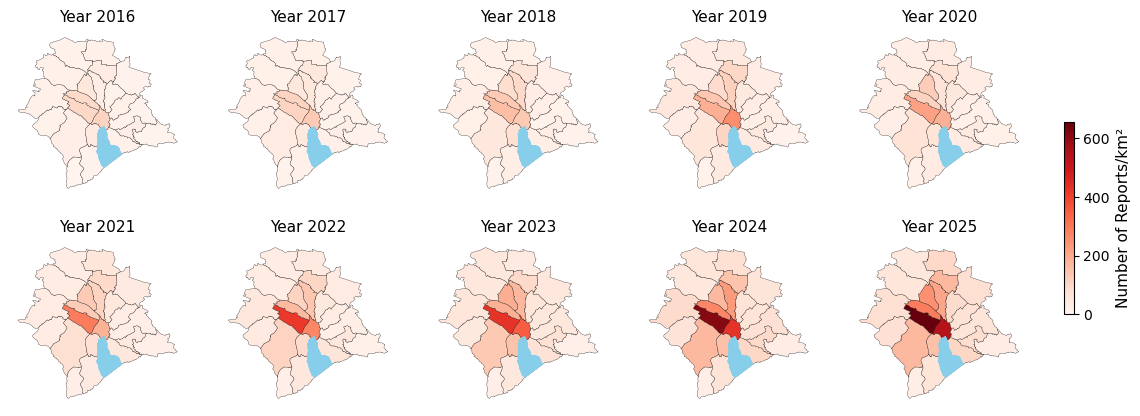

In [37]:
# Group by year and calculate the number of reports
yearly_counts = reports_quartiere_gdf.groupby(["year", "name"]).size().reset_index(name="count")

# Standardisation
yearly_density = yearly_counts.merge(quartiere_gdf[["name", "area_km2"]], on="name")
yearly_density["density"] = yearly_density["count"] / yearly_density["area_km2"]
max_yearly_density = yearly_density["density"].max()

# Create choropleth maps
fig, axs = plt.subplots(2,5, figsize=(16,5))
axs = axs.flatten()

years = range(2016, 2026)

for i, year in enumerate(years):
    ax = axs[i]
    counts_year = yearly_counts[yearly_counts["year"] == year]
    yearly_map_gdf = quartiere_gdf.merge(counts_year, on="name", how="left")

    yearly_map_gdf["density"] = yearly_map_gdf["count"] / yearly_map_gdf["area_km2"]
    
    yearly_map_gdf.plot(column="density", cmap="Reds", vmin=0, vmax=max_yearly_density, 
                  edgecolor="black", linewidth=0.2, ax=ax)
    lakes_gdf.plot(ax=ax, color="skyblue", zorder=2)
    
    ax.set_title(f"Year {year}", fontsize=11)
    ax.axis("off")

sm = plt.cm.ScalarMappable(cmap="Reds", norm=plt.Normalize(vmin=0, vmax=max_yearly_density))
sm._A = [] 
cbar = fig.colorbar(sm, ax=axs, orientation="vertical", shrink=0.5, pad=0.03)
cbar.set_label("Number of Reports/km²", fontsize=11)

plt.savefig("../outputs/reports_yearly_choropleth.png", dpi=300, bbox_inches="tight")

plt.show()


## 3.2 Reports per Year Histogram

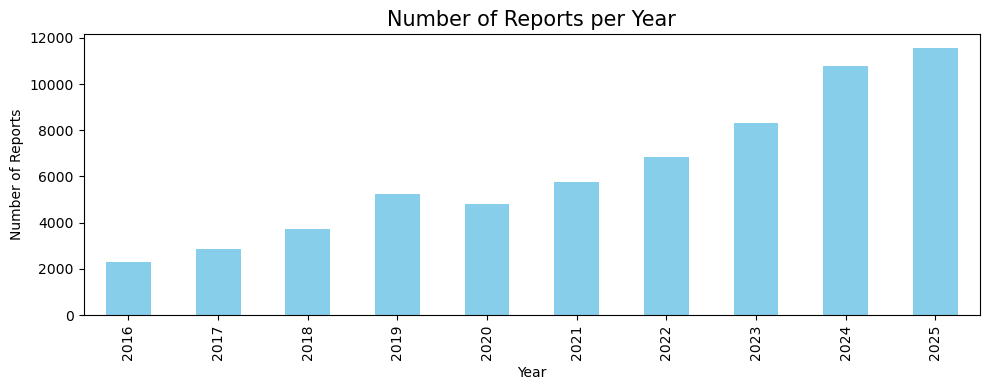

In [ ]:
fig, ax = plt.subplots(figsize=(10,4))

reports_gdf["year"].value_counts().sort_index().plot(kind="bar", ax=ax, color="skyblue")

ax.set_title("Number of Reports per Year", fontsize=15)
ax.set_ylabel("Number of Reports")
ax.set_xlabel("Year")

plt.tight_layout()
plt.savefig("../outputs/reports_per_year.png", dpi=300, bbox_inches="tight")
plt.show()

## 3.3 How does the number of reports vary over time or between neighbourhoods?

The provided series of choropleth maps and the histogram illustrates the evolution of reporting density (reports per km²) across Zurich's districts over a ten-year period. The data reveals two primary trends: a significant temporal increase in total reports and a persistent geographical concentration in the city center.

There is a striking upward trend in the number of reports over the decade. In the early years (2016–2018), the maps appear relatively pale, indicating a low reporting density across most districts. However, starting in 2019, the color intensity increases significantly. By 2024, the density in the most active areas has more than doubled compared to 2016, reaching peaks of over 600 reports per km². The fact that 2025 already shows such high values suggests that the frequency of reporting is continuing to accelerate.

Despite the overall increase in volume, the spatial distribution remains remarkably consistent. The "hotspots" are invariably located in the central districts, particularly in Aussersihl (District 4) and the Altstadt (District 1). These areas consistently show the highest density, represented by the deep red shades. In contrast, the peripheral and more residential districts (such as Witikon, Höngg, or Affoltern) remain light-colored throughout the entire period, indicating that the challenges being reported are predominantly an urban-center phenomenon.

This overall increas in the numer of reports might be a result of several factors:
- The rising popularity of mobile reporting due to the digitalisation makes it easier for citizens to report infrastructure issues, waste, or maintenance needs.
-  As the city center become more densely used for work, nightlife, and tourism, the likelihood of reportable incidents (e.g., littering, noise, or damage) increased.
- A growing sense of civic responsibility and higher expectations regarding urban cleanliness and maintenance likely contribute to the surge in data points.

# 4. Waste-Related Reports
This section investigates whether the spatial distribution of waste-related reports is related to the availability of waste disposal infrastructure, measured through the density of waste containers across districts.
## 4.1 Distribution of Report Types
An examination of the histogram below reveals that the waste related reports is by far the most frequent reporting category, with nearly 25'000 reports recorded over the last ten years. 

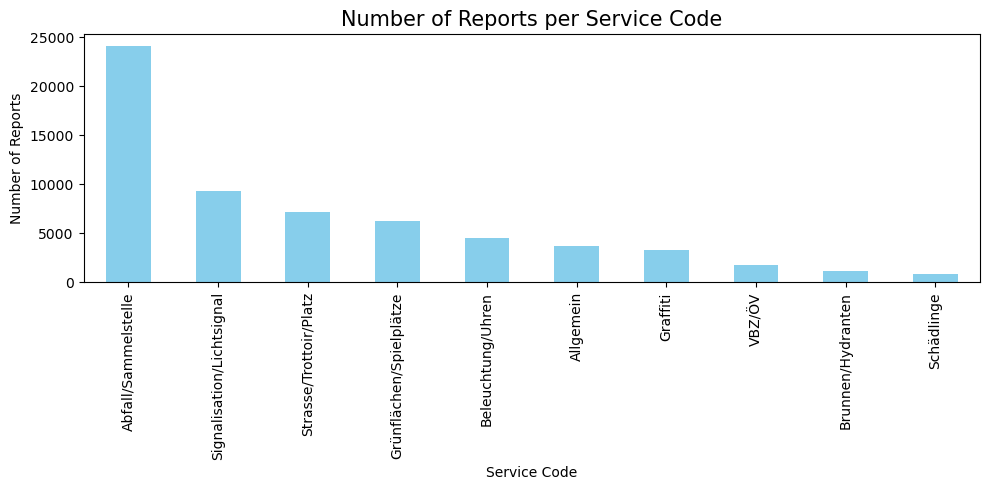

In [ ]:
# Histogram of Number of Reports per Service Code
fig, ax = plt.subplots(figsize=(10,5))

reports_gdf["service_code"].value_counts().plot(kind="bar", ax=ax, color="skyblue")

ax.set_title("Number of Reports per Service Code", fontsize=15)
ax.set_ylabel("Number of Reports")
ax.set_xlabel("Service Code")

plt.tight_layout()
plt.savefig("../outputs/reports_per_service_code.png", dpi=300, bbox_inches="tight")
plt.show()

## 4.2 Spatial Distribution of Waste-Related Reports

To further investigate the high concentration of waste-related reports, the spatial distribution of public waste containers is analysed across Zurich's districts. Its spatial density distribution closely mirrors the overall reporting pattern. Aussersihl exhibits the highest concentration by a significant margin, exceeding 2'000 reports per km², followed by the surrounding districts. To determine whether this trend is linked to the availability of disposal infrastructure, the following section will analyze the distribution of waste containers in more detail.

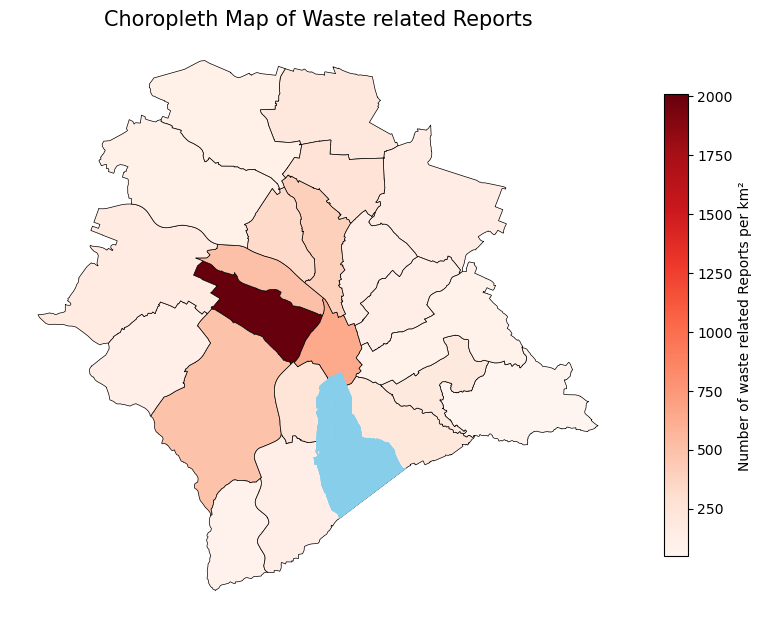

In [ ]:
# Choropleth Map of waste related Reports
fig, ax = plt.subplots(figsize=(8,8))

# Filter waste-related reports (already spatially joined data)
waste_reports_gdf = reports_quartiere_gdf[reports_quartiere_gdf["service_code"] == "Abfall/Sammelstelle"]

# Aggregate by district
waste_counts = (waste_reports_gdf.groupby("name").size().reset_index(name="count"))

# Merge with district geometries
quartiere_waste_gdf = quartiere_gdf.merge(waste_counts, on="name", how="left")

# Standardization
quartiere_waste_gdf["count"] = quartiere_waste_gdf["count"].fillna(0)
quartiere_waste_gdf["density"] = quartiere_waste_gdf["count"] / quartiere_waste_gdf["area_km2"]

lakes_gdf.plot(ax=ax, color="skyblue", zorder=2)

quartiere_waste_gdf.plot(
    column="density",
    cmap="Reds",
    legend=True,
    legend_kwds={
        "label": "Number of waste related Reports per km²",
        "orientation": "vertical",
        "shrink": 0.6},
    edgecolor="black",
    linewidth=0.5,
    ax=ax,
    zorder=1)

ax.set_title("Choropleth Map of Waste related Reports", fontsize=15)
ax.axis("off")

plt.tight_layout()
plt.savefig("../outputs/waste_reports_choropleth.png", dpi=300, bbox_inches="tight")
plt.show()

## 4.3 Spatial Distribution of Waste Containers

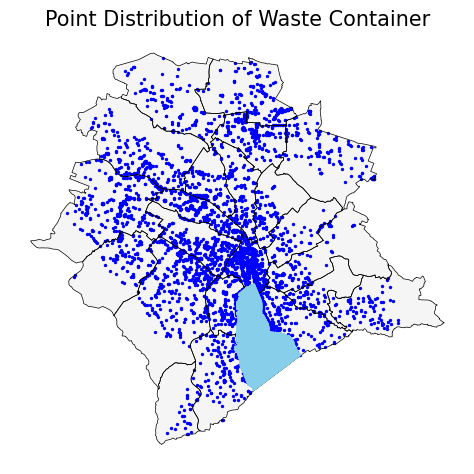

In [ ]:
waste_containers = gpd.read_file("../data/raw/abfallgefaesse.gpkg")
waste_containers = waste_containers.to_crs(epsg=2056)

# 1. Point Distribution Map
fig, ax = plt.subplots(1,1, figsize=(7, 5))

quartiere_gdf.plot(ax=ax, color="whitesmoke", linewidth=0.5, zorder=1)

waste_containers.plot(
    ax=ax,
    color="blue",
    markersize=2,
    zorder=2,
    label="Waste container")

lakes_gdf.plot(ax=ax, color="skyblue", zorder=4)

quartiere_gdf.boundary.plot(ax=ax, color="black", linewidth=0.5, zorder=3)

ax.axis("off")
ax.set_title("Point Distribution of Waste Container", fontsize=15)

plt.tight_layout()
plt.savefig("../outputs/waste_container_points.png", dpi=300, bbox_inches="tight")
plt.show()

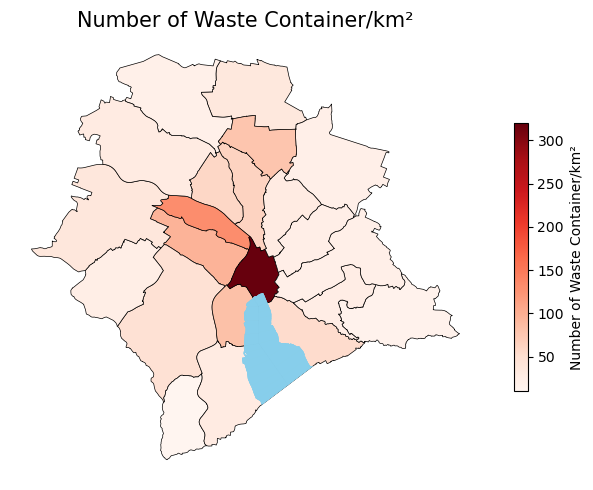

In [ ]:
# Spatial Join
waste_quartiere_gdf = gpd.sjoin(waste_containers, quartiere_gdf, how="inner", predicate="within")
waste_container_counts = waste_quartiere_gdf.groupby("name").size().reset_index(name="count")
quartiere_waste_container_counts_gdf = quartiere_gdf.merge(waste_container_counts, on="name", how="left")

# Standardization
quartiere_waste_container_counts_gdf["density"] = quartiere_waste_container_counts_gdf["count"] / quartiere_waste_container_counts_gdf["area_km2"]

fig, ax = plt.subplots(1,1, figsize=(7, 5))

lakes_gdf.plot(ax=ax, color="skyblue", zorder=2)

quartiere_waste_container_counts_gdf.plot(
    column="density",
    cmap="Reds",
    legend=True,
    legend_kwds={"label": "Number of Waste Container/km²", "orientation": "vertical", "shrink": 0.6},
    edgecolor="black",
    linewidth=0.5,
    ax=ax,
    zorder=1)

ax.set_title("Number of Waste Container/km²", fontsize=15)
ax.axis("off")

plt.tight_layout()
plt.savefig("../outputs/waste_container_choropleth.png", dpi=300, bbox_inches="tight")
plt.show()

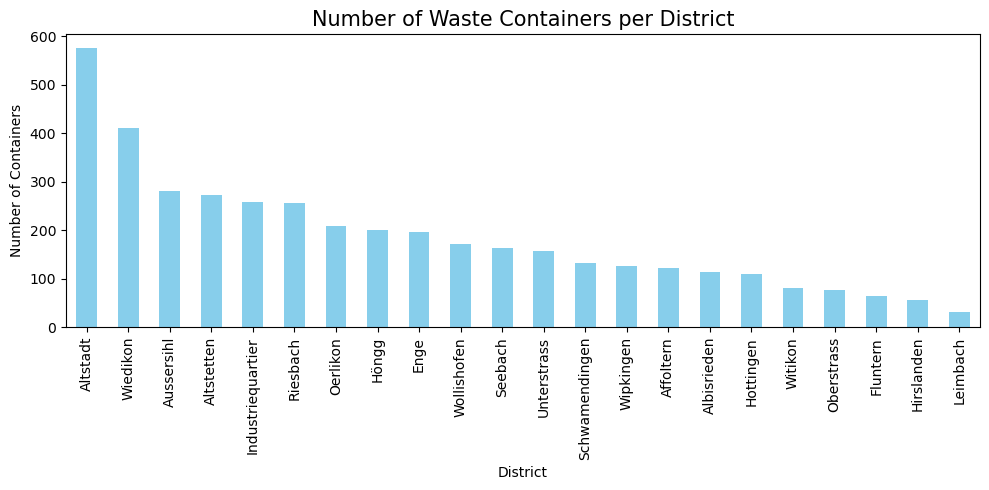

In [ ]:
waste_container_quartier = gpd.sjoin(waste_containers, quartiere_gdf[["name", "geometry"]], how="inner", predicate="within")

waste_container_counts = waste_container_quartier.groupby("name").size().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))

waste_container_counts.plot(
    kind="bar", 
    ax=ax, 
    color="skyblue")

ax.set_title("Number of Waste Containers per District", fontsize=15)
ax.set_ylabel("Number of Containers")
ax.set_xlabel("District")

plt.tight_layout()
plt.savefig("../outputs/waste_containers_per_district.png", dpi=300, bbox_inches="tight")
plt.show()

The distribution of waste containers is highly uneven across Zurich. Central districts contain substantially more public waste infrastructure than peripheral residential areas. This reflects differences in population density, commercial activity, tourism, and pedestrian traffic.

## 4.4 Relationship Between Waste Containers and Waste Reports

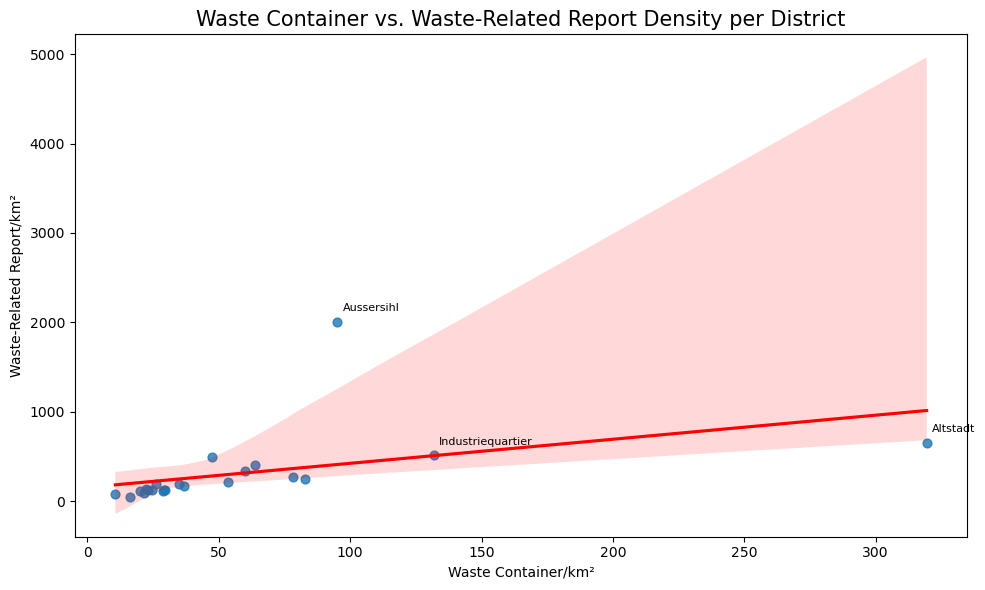

In [36]:
# Regressionplot Waste Container vs. Report Density per District
df_container = quartiere_waste_container_counts_gdf[["name", "density"]].rename(columns={"density": "container_density"})
df_reports = quartiere_waste_gdf[["name", "density"]].rename(columns={"density": "report_density"})
analysis_df = df_container.merge(df_reports, on="name")

plt.figure(figsize=(10, 6))

sns.regplot(
    data=analysis_df,
    x="container_density",
    y="report_density",
    scatter_kws={"s":40},
    line_kws={"color":"red"})

for i, row in analysis_df.iterrows():
    if row["report_density"] > 500 or row["container_density"] > 200:
        plt.text(
            row["container_density"]+2,
            row["report_density"]+120,
            row["name"],
            fontsize=8
        )
plt.title("Waste Container vs. Waste-Related Report Density per District", fontsize=15)
plt.xlabel("Waste Container/km²")
plt.ylabel("Waste-Related Report/km²")

plt.tight_layout()

plt.savefig("../outputs/scatter_container_reports.png", dpi=300)
plt.show()

The regression plot visualises the general linear relationship between waste container density and waste-related report density across districts. The upward-sloping trend line indicates a moderate positive association, meaning that districts with a higher density of waste containers also tend to exhibit higher densities of waste-related reports. However, the considerable spread of observations around the regression line and the presence of two extreme outliers (Aussershil and Altstadt) suggest that the relationship is relatively weak and influenced by additional urban factors.

The observed relationship should not be interpreted causally. Districts with high container densities are also highly urbanised and densely frequented areas. Therefore, both variables are likely influenced by broader urban activity patterns rather than one directly causing the other.

## 4.5 Pearson Correlation

In [ ]:
correlation = analysis_df["container_density"].corr(analysis_df["report_density"])
print("Pearson-Korrelation:", correlation)

r, p = pearsonr(
    analysis_df["container_density"],
    analysis_df["report_density"])

print(r, p)

Pearson-Korrelation: 0.4311716279023768
0.4311716279023766 0.045126762327458866


The Pearson correlation analysis resulted in a moderate positive correlation (r = 0.43) between waste container density and waste-related report density. The relationship was statistically significant at the 5% significance level (p = 0.045), suggesting that districts with higher concentrations of waste containers also tend to exhibit higher densities of waste-related reports.

However, the relationship should be interpreted with caution. The relatively small number of districts and the presence of several influential outliers may affect the robustness of the correlation. In addition, both variables are likely influenced by broader urban characteristics such as population density, pedestrian traffic, commercial activity, and tourism intensity.

# 5. Conclusion and Limitations

The analysis shows clear and consistent spatial inequalities in reporting activity across Zurich. Central districts exhibit substantially higher report densities compared to peripheral residential areas, indicating a strong concentration of urban maintenance issues in the city center. Over time, the data also reveals a marked increase in total reports, suggesting growing reporting activity that is likely influenced by digital reporting platforms, intensified urban usage, and changing civic engagement.

The investigation of waste-related reports further confirms this spatial pattern. These reports are highly concentrated in central districts and closely align with areas of high pedestrian activity and urban density. While waste container density shows a moderate positive correlation with waste-related reports, this relationship is not strong enough to explain the spatial distribution on its own. This indicates that broader urban factors such as population density, tourism, nightlife, and commercial activity likely play a more important role.

Spatial autocorrelation analysis (Global Moran’s I) confirms that the observed patterns are not randomly distributed. Instead, reporting activity is significantly clustered in space, particularly around central urban districts. This reinforces the finding that urban structure strongly shapes where reports occur.

However, several limitations should be considered. The analysis is aggregated at district level, which may hide finer spatial variations within districts (modifiable areal unit problem). Additionally, the number of spatial units is relatively small, which can affect the stability of statistical measures such as Moran’s I and Pearson correlation. The analysis is also purely descriptive and does not establish causality between variables such as waste container density and report frequency.

Finally, reporting behavior itself may be influenced by external factors such as digital accessibility, awareness of reporting tools, and changes in administrative processes over time. As a result, increases in reported incidents may partially reflect changes in reporting behavior rather than actual changes in infrastructure conditions.